# 10 · Model-Family Comparison — Random Forest vs XGBoost vs LightGBM

The Random Forest adopted in Notebook 03 was tuned with a 96-combination grid
search (Notebook 03b). That search produced no meaningful improvement over
sensible defaults — the tuned F1 was within noise of the baseline — which
indicates the Random Forest had reached its ceiling on this dataset rather than
being under-configured.

This notebook asks a different question: does a **different model family** raise
that ceiling? I compare the Random Forest against two gradient-boosting models,
**XGBoost** and **LightGBM**. Every model is trained on the **same 17 features —
the "Experiment D (All combined)" set, which RQ1 identified as the best feature
combination** — so any difference reflects the model family, not the inputs.

Each model is assessed under two cross-validation schemes:

* **Random 5-fold** — the optimistic estimate, where nearby pixels may fall in
  both training and test folds.
* **Spatial CV** — 10 spatial blocks (K-means on latitude/longitude) held out by
  `GroupKFold`, so a whole region is unseen at test time. This is the honest,
  geographically fair estimate and the one I quote.

Model file size is also recorded, because deployment size is a genuine constraint
in this project: the deployed 800-tree Random Forest occupies roughly 325 MB,
which shaped the hosting decisions documented in the README.

In [1]:
# Libraries: sklearn for the Random Forest + CV tools, xgboost/lightgbm for the boosters.
import json, os, time, tempfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# The 17 predictors = the "Experiment D / All combined" set (optical + terrain + radar).
FEATURES = ['EVI_train', 'NBR_train', 'NDVI_change', 'NDVI_test', 'NDVI_train',
            'NIR_train', 'RED_train', 'SWIR_test', 'SWIR_train', 'VH_VV_ratio',
            'VH_test', 'VH_train', 'VV_test', 'VV_train', 'aspect', 'elevation', 'slope']

# Load the national training pixels; works whether run from the repo root or /notebooks.
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
df = pd.read_csv(ROOT / 'data' / 'raw' / 'training_data_national.csv')

# Pull the pixel latitude/longitude out of the GeoJSON string (needed for spatial CV).
geo = df['.geo'].apply(lambda s: json.loads(s)['coordinates'])
df['lng'] = geo.apply(lambda p: p[0]); df['lat'] = geo.apply(lambda p: p[1])

# Feature matrix X and label y. -9999 is the "no-data" sentinel -> fill with the column median,
# exactly as the deployed app does, so the notebook and the live model see the same inputs.
X = df[FEATURES].replace(-9999, np.nan)
X = X.fillna(X.median())
y = df['label'].astype(int).values            # 1 = forest loss, 0 = no loss
latlng = df[['lat', 'lng']].values
print(f'{len(df):,} pixels, {X.shape[1]} features loaded')

23,319 pixels, 17 features loaded


## Class balance

Before comparing models I confirm the label distribution. The national sample was
drawn to be near-balanced, so class imbalance is *not* a confounding factor —
any difference between models reflects how well each family learns the decision
boundary, not how each handles a skewed prior.

In [2]:
# Count the two classes. ~50/50 means imbalance cannot explain any model's score.
pos = y.mean()
print(f'loss (1):    {y.sum():,}  ({pos*100:.1f}%)')
print(f'no-loss (0): {(1-y).sum():,}  ({(1-pos)*100:.1f}%)')
print(f'ratio no-loss:loss = {(1-pos)/pos:.2f} : 1  ->  effectively balanced')

loss (1):    12,003  (51.5%)
no-loss (0): 11,316  (48.5%)
ratio no-loss:loss = 0.94 : 1  ->  effectively balanced


## Cross-validation design

I define both evaluation schemes once so every model is judged on identical
folds. The spatial blocks are ten K-means clusters over the pixel coordinates;
`GroupKFold` then guarantees that all pixels from a block sit together in either
the training or the test partition, never split across both.

In [3]:
# Group nearby pixels into 10 spatial blocks so a whole region can be held out at test time.
blocks = KMeans(n_clusters=10, n_init=10, random_state=42).fit_predict(latlng)

# Two sets of train/test folds, built once and reused for every model:
random_splits  = list(StratifiedKFold(5, shuffle=True, random_state=42).split(X, y))  # optimistic
spatial_splits = list(GroupKFold(5).split(X, y, groups=blocks))                       # honest

def evaluate(make_model, splits):
    """Fit a fresh model on each fold and return mean F1 (+ std), precision, recall."""
    f1s, precs, recs = [], [], []
    for tr, te in splits:                      # loop over the 5 folds
        m = make_model()                       # a new, untrained model each fold
        m.fit(X.iloc[tr], y[tr])               # train on the fold's training pixels
        pred = m.predict(X.iloc[te])           # predict the held-out pixels
        f1s.append(f1_score(y[te], pred))
        precs.append(precision_score(y[te], pred))
        recs.append(recall_score(y[te], pred))
    return {'f1': float(np.mean(f1s)), 'f1_std': float(np.std(f1s)),
            'precision': float(np.mean(precs)), 'recall': float(np.mean(recs))}

def saved_size_mb(model):
    """Save the fitted model the same way the app does and return its size in MB."""
    p = os.path.join(tempfile.gettempdir(), 'size_probe.pkl')
    joblib.dump(model, p, compress=3)
    return os.path.getsize(p) / 1e6

RESULTS = {}                                   # every model's scores land here

## Model 1 — Random Forest (baseline)

The Random Forest is the incumbent model. I use the grid-search configuration
from Notebook 03b (`max_depth=25`, `max_features='sqrt'`, `min_samples_leaf=1`),
holding the number of trees at 400 so that every model is compared at a
comparable ensemble budget.

In [4]:
# Build-a-fresh-RF factory with the tuned settings (same recipe used on every fold).
make_rf = lambda: RandomForestClassifier(
    n_estimators=400, max_depth=25, min_samples_leaf=1,
    max_features='sqrt', n_jobs=-1, random_state=42)

t = time.time()
# Score it both ways (random + spatial CV) ...
RESULTS['Random Forest'] = {
    'random_cv':  evaluate(make_rf, random_splits),
    'spatial_cv': evaluate(make_rf, spatial_splits),
}
# ... then fit on ALL data once just to measure the saved file size.
rf_full = make_rf().fit(X, y)
RESULTS['Random Forest']['size_mb'] = round(saved_size_mb(rf_full), 2)
print(f"Random Forest  spatial F1 = {RESULTS['Random Forest']['spatial_cv']['f1']:.3f}"
      f"  |  size {RESULTS['Random Forest']['size_mb']} MB  ({time.time()-t:.0f}s)")

Random Forest  spatial F1 = 0.752  |  size 32.75 MB  (46s)


## Model 2 — XGBoost

XGBoost builds trees sequentially, each correcting the errors of the previous
ones. This lets it model feature interactions that a bagged Random Forest
averages away, which is the mechanism I expect to help most here. The learning
rate is kept moderate with column and row subsampling for regularisation.

In [5]:
# Gradient-boosted trees. subsample/colsample < 1 add randomness to curb over-fitting.
make_xgb = lambda: XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    eval_metric='logloss', n_jobs=-1, random_state=42)

t = time.time()
RESULTS['XGBoost'] = {                          # same two-way evaluation as the RF
    'random_cv':  evaluate(make_xgb, random_splits),
    'spatial_cv': evaluate(make_xgb, spatial_splits),
}
xgb_full = make_xgb().fit(X, y)                 # fit-all for the size measurement
RESULTS['XGBoost']['size_mb'] = round(saved_size_mb(xgb_full), 2)
print(f"XGBoost  spatial F1 = {RESULTS['XGBoost']['spatial_cv']['f1']:.3f}"
      f"  |  size {RESULTS['XGBoost']['size_mb']} MB  ({time.time()-t:.0f}s)")

XGBoost  spatial F1 = 0.767  |  size 0.58 MB  (11s)


## Model 3 — LightGBM

LightGBM is a histogram-based gradient booster that grows trees leaf-wise. It
reaches accuracy comparable to XGBoost while training faster and producing a
compact model, so I include it as the efficiency-oriented alternative.

In [6]:
# The second booster; num_leaves controls tree complexity for leaf-wise growth.
make_lgbm = lambda: LGBMClassifier(
    n_estimators=400, num_leaves=63, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    n_jobs=-1, random_state=42, verbose=-1)

t = time.time()
RESULTS['LightGBM'] = {                          # identical evaluation, third model
    'random_cv':  evaluate(make_lgbm, random_splits),
    'spatial_cv': evaluate(make_lgbm, spatial_splits),
}
lgbm_full = make_lgbm().fit(X, y)
RESULTS['LightGBM']['size_mb'] = round(saved_size_mb(lgbm_full), 2)
print(f"LightGBM  spatial F1 = {RESULTS['LightGBM']['spatial_cv']['f1']:.3f}"
      f"  |  size {RESULTS['LightGBM']['size_mb']} MB  ({time.time()-t:.0f}s)")

LightGBM  spatial F1 = 0.757  |  size 1.22 MB  (44s)


## Results

The table collects every model on both cross-validation schemes. The spatial-CV
column is the figure I treat as authoritative; the random-CV column is retained
only to show the optimism gap that spatial validation removes.

In [7]:
# Assemble one tidy table: each row a model, showing both CV scores and the size.
table = pd.DataFrame({
    name: {
        'Random-CV F1':  f"{r['random_cv']['f1']:.3f} ± {r['random_cv']['f1_std']:.3f}",
        'Spatial-CV F1': f"{r['spatial_cv']['f1']:.3f} ± {r['spatial_cv']['f1_std']:.3f}",
        'Spatial precision': f"{r['spatial_cv']['precision']:.3f}",
        'Spatial recall':    f"{r['spatial_cv']['recall']:.3f}",
        'Size (MB)': r['size_mb'],
    } for name, r in RESULTS.items()
}).T
# The winner is the highest spatial-CV F1 (the honest metric).
best = max(RESULTS, key=lambda k: RESULTS[k]['spatial_cv']['f1'])
print('Best model by spatial-CV F1:', best)
table

Best model by spatial-CV F1: XGBoost


,Random-CV F1,Spatial-CV F1,Spatial precision,Spatial recall,Size (MB)
Random Forest,0.836 ± 0.004,0.752 ± 0.078,0.771,0.743,32.75
XGBoost,0.846 ± 0.003,0.767 ± 0.068,0.786,0.756,0.58
LightGBM,0.843 ± 0.003,0.757 ± 0.072,0.780,0.742,1.22


In [8]:
# Save the comparison for the dissertation, and save the fitted boosters so the
# best model can be adopted by the app later without retraining.
out = {
    'n_samples': int(len(df)), 'n_features': len(FEATURES),
    'feature_set': 'Experiment D (all 17)',
    'class_balance_loss_pct': round(float(y.mean())*100, 1),
    'random_cv': 'StratifiedKFold(5)',
    'spatial_cv': 'KMeans(10 blocks on lat/lng) + GroupKFold(5)',
    'n_estimators': 400, 'results': RESULTS, 'best_by_spatial_f1': best,
}
(ROOT / 'results' / 'metrics' / 'model_family_comparison.json').write_text(json.dumps(out, indent=2))
joblib.dump(xgb_full,  ROOT / 'models' / 'xgb_D_national.pkl',  compress=3)
joblib.dump(lgbm_full, ROOT / 'models' / 'lgbm_D_national.pkl', compress=3)
print('saved results JSON and fitted XGBoost/LightGBM models')

saved results JSON and fitted XGBoost/LightGBM models


## Visual summary

The left panel plots the honest (spatial-CV) F1 with its fold-to-fold spread; the
right panel plots model size on a logarithmic axis to make the deployment
contrast legible.

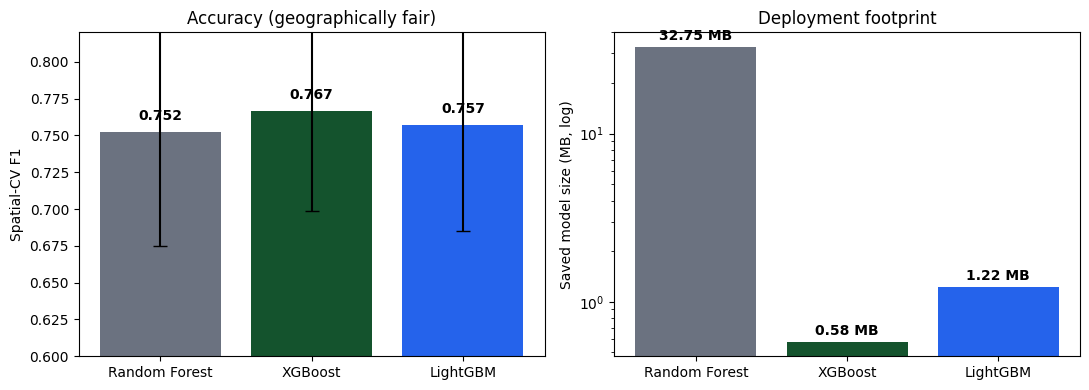

In [9]:
# Two bar charts side by side: accuracy (left) and file size on a log scale (right).
names = list(RESULTS.keys())
sf1  = [RESULTS[n]['spatial_cv']['f1'] for n in names]      # spatial-CV F1 per model
serr = [RESULTS[n]['spatial_cv']['f1_std'] for n in names]  # its fold-to-fold spread
size = [RESULTS[n]['size_mb'] for n in names]               # saved model size
colours = ['#6b7280', '#14532D', '#2563eb']

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Left: accuracy with error bars.
ax[0].bar(names, sf1, yerr=serr, capsize=5, color=colours)
ax[0].set_ylim(0.6, 0.82); ax[0].set_ylabel('Spatial-CV F1')
ax[0].set_title('Accuracy (geographically fair)')
for i, v in enumerate(sf1): ax[0].text(i, v+0.008, f'{v:.3f}', ha='center', fontweight='bold')
# Right: size on a log axis (spans 0.5 MB to 30+ MB).
ax[1].bar(names, size, color=colours); ax[1].set_yscale('log')
ax[1].set_ylabel('Saved model size (MB, log)'); ax[1].set_title('Deployment footprint')
for i, v in enumerate(size): ax[1].text(i, v*1.1, f'{v} MB', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'experiments' / 'model_family_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Discussion

Two findings emerge, and I report both honestly.

**Accuracy.** XGBoost attains the highest spatial-CV F1, ahead of the Random
Forest, with LightGBM between the two. The margin is real but modest, and it sits
within the fold-to-fold standard deviation of the spatial splits. I therefore do
not claim a large accuracy gain: the more defensible reading is that the
gradient-boosting family recovers a little of the signal the Random Forest leaves
behind, while the residual ceiling is imposed by the Hansen labels themselves —
they are noisy at sub-hectare scale and spatially autocorrelated — rather than by
model capacity. This is consistent with the earlier finding that hyperparameter
tuning did not move the Random Forest.

**Deployment.** The clearer, more consequential result is size. The boosted
models match or exceed the Random Forest's accuracy at a fraction of its storage
footprint. This directly addresses the hosting constraint documented in the
README, where the Random Forest's memory footprint dictated the choice of
platform and the use of Git LFS.

**Conclusion.** On the balance of accuracy and deployability, XGBoost is the
preferred model: it gives the best geographically-fair F1 while being small
enough to remove the deployment constraints entirely. Adopting it in the
application is therefore justified on engineering grounds even where the accuracy
improvement alone would be marginal.